## Change1 gumbel_softmax into implicit function
## Change2 separate adversal agent from collaborate agents
## Change3 adversary agent uses DDPG ; Collaborate agents use MADDPG

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
import rl_utils

In [3]:
!git clone https://github.com/boyu-ai/multiagent-particle-envs.git --quiet
!pip install -e multiagent-particle-envs
import sys
sys.path.append("multiagent-particle-envs")
# 由于multiagent-pariticle-env底层的实现有一些版本问题,因此gym需要改为可用的版本
# !pip install --upgrade gym==0.10.5 -q
import gym
from multiagent.environment import MultiAgentEnv
import multiagent.scenarios as scenarios


def make_env(scenario_name):
    # 从环境文件脚本中创建环境
    scenario = scenarios.load(scenario_name + ".py").Scenario()
    world = scenario.make_world()
    env = MultiAgentEnv(world, scenario.reset_world, scenario.reward,
                        scenario.observation)
    return env

fatal: destination path 'multiagent-particle-envs' already exists and is not an empty directory.


Obtaining file:///home/multiagent/Desktop/RL/Hands-on-RL-main/HandsOn/multiagent-particle-envs
  Preparing metadata (setup.py) ... done
  Attempting uninstall: multiagent
    Found existing installation: multiagent 0.0.1
    Uninstalling multiagent-0.0.1:
      Successfully uninstalled multiagent-0.0.1
  Running setup.py develop for multiagent


In [4]:
logits =torch.tensor([1,3,2,4,5,6]).reshape(-1, 3) #[2*3]
argmax_acs = (logits == logits.max(1, keepdim=True)[0]).float()
print(argmax_acs)

rand_acs = torch.autograd.Variable(torch.eye(logits.shape[1])[[
        np.random.choice(range(logits.shape[1]), size=logits.shape[0])
    ]],
                                       requires_grad=False).to(logits.device)
print(rand_acs)

print(torch.rand(logits.shape[0]))
print(list(enumerate(torch.rand(logits.shape[0]))))

tensor([[0., 1., 0.],
        [0., 0., 1.]])
tensor([[0., 0., 1.],
        [1., 0., 0.]])
tensor([0.1231, 0.5720])
[(0, tensor(0.7591)), (1, tensor(0.2424))]


In [5]:
def onehot_from_logits(logits, eps=0.01):# 随即产生动作
    ''' 生成最优动作的（one-hot）形式 '''
    #生成最优动作的one-hot形式
    argmax_acs = (logits == logits.max(1, keepdim=True)[0]).float()
    
    # 生成随机动作,转换成独热形式
    rand_acs = torch.autograd.Variable(torch.eye(logits.shape[1])[[
        np.random.choice(range(logits.shape[1]), size=logits.shape[0])
    ]], requires_grad=False).to(logits.device)
    # 通过epsilon-greedy算法来选择用哪个动作
    return torch.stack([
        argmax_acs[i] if r > eps else rand_acs[i]
        for i, r in enumerate(torch.rand(logits.shape[0]))
    ])

logits =torch.tensor([1.,3.,2.,4.,5.,6.]).reshape(-1, 3)
print(F.gumbel_softmax(logits, tau=1, hard=False))
print(onehot_from_logits(F.gumbel_softmax(logits, tau=1, hard=False)))
print(F.gumbel_softmax(logits, tau=1, hard=True))# that's the one we want

tensor([[0.0567, 0.8149, 0.1284],
        [0.0943, 0.1971, 0.7086]])
tensor([[0., 0., 1.],
        [0., 1., 0.]])
tensor([[0., 1., 0.],
        [0., 0., 1.]])


@ properity usage

https://www.liaoxuefeng.com/wiki/1016959663602400/1017502538658208

In [6]:
def onehot_from_logits(logits, eps=0.01):# 随即产生动作
    ''' 生成最优动作的（one-hot）形式 '''
    #生成最优动作的one-hot形式
    argmax_acs = (logits == logits.max(1, keepdim=True)[0]).float()
    
    # 生成随机动作,转换成独热形式
    rand_acs = torch.autograd.Variable(torch.eye(logits.shape[1])[[
        np.random.choice(range(logits.shape[1]), size=logits.shape[0])
    ]], requires_grad=False).to(logits.device)
    # 通过epsilon-greedy算法来选择用哪个动作
    return torch.stack([
        argmax_acs[i] if r > eps else rand_acs[i]
        for i, r in enumerate(torch.rand(logits.shape[0]))
    ])


# def sample_gumbel(shape, eps=1e-20, tens_type=torch.FloatTensor):#生成重参数因子gi
#     """从Gumbel(0,1)分布中采样（重参数因子）"""
#     U = torch.autograd.Variable(tens_type(*shape).uniform_(),
#                                 requires_grad=False)
#     return -torch.log(-torch.log(U + eps) + eps)


# def gumbel_softmax_sample(logits, temperature):
#     """ 从Gumbel-Softmax分布中采样"""
#     y = logits + sample_gumbel(logits.shape, tens_type=type(logits.data)).to(
#         logits.device)
#     # (log ai + gi)
#     return F.softmax(y / temperature, dim=1)


def gumbel_softmax(logits, temperature=1.0):# able to gradientdescent
    """从Gumbel-Softmax分布中采样,并进行离散化"""
    # y = gumbel_softmax_sample(logits, temperature)
    # y_hard = onehot_from_logits(y)
    # y = (y_hard.to(logits.device) - y).detach() + y
    # # 返回一个y_hard的独热量,但是它的梯度是y,我们既能够得到一个与环境交互的离散动作,又可以
    # # 正确地反传梯度
    # return y
    y = F.gumbel_softmax(logits, tau=temperature, hard=False)
    y_hard = onehot_from_logits(y)# epsilon Greedy inside
    y = (y_hard.to(logits.device) - y).detach() + y
    return y



In [7]:
class TwoLayerFC(torch.nn.Module):
    def __init__(self, num_in, num_out, hidden_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(num_in, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = torch.nn.Linear(hidden_dim, num_out)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class DDPGCol:
    ''' DDPG算法 '''
    def __init__(self, state_dim, action_dim, critic_input_dim, hidden_dim, actor_lr, critic_lr, device):
        self.actor = TwoLayerFC(state_dim, action_dim, hidden_dim).to(device)
        self.target_actor = TwoLayerFC(state_dim, action_dim, hidden_dim).to(device)
        self.critic = TwoLayerFC(critic_input_dim, 1, hidden_dim).to(device)
        self.target_critic = TwoLayerFC(critic_input_dim, 1, hidden_dim).to(device)
        self.target_critic.load_state_dict(self.critic.state_dict())
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

    def take_action(self, state, explore=False):
        action = self.actor(state)
        if explore:
            action = gumbel_softmax(action) # 可以backprop
        else:
            action = onehot_from_logits(action) #不能 backprop
        return action.detach().cpu().numpy()[0]

    def soft_update(self, net, target_net, tau):# soft update
        for param_target, param in zip(target_net.parameters(), net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - tau) + param.data * tau)


In [8]:
class DDPGAdv:
    ''' DDPG算法for adversary agent '''
    def __init__(self, state_dim, action_dim, critic_input_dim, hidden_dim, actor_lr, critic_lr, device):
        self.actor = TwoLayerFC(state_dim, action_dim, hidden_dim).to(device)
        self.target_actor = TwoLayerFC(state_dim, action_dim, hidden_dim).to(device)
        self.critic = TwoLayerFC(critic_input_dim, 1, hidden_dim).to(device)
        self.target_critic = TwoLayerFC(critic_input_dim, 1, hidden_dim).to(device)
        self.target_critic.load_state_dict(self.critic.state_dict())
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

    def take_action(self, state, explore=False):
        action = self.actor(state)
        if explore:
            action = gumbel_softmax(action) # 可以backprop
        else:
            action = onehot_from_logits(action) #不能 backprop
        return action.detach().cpu().numpy()[0]

    def soft_update(self, net, target_net, tau):# soft update
        for param_target, param in zip(target_net.parameters(), net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - tau) + param.data * tau)

    # def update(self, transition_dict):
    #     states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
    #     actions = torch.tensor(transition_dict['actions'], dtype=torch.float).view(-1, 1).to(self.device)
    #     rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
    #     next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
    #     dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

    #     next_q_values = self.target_critic(next_states, self.target_actor(next_states)) #using target network
    #     q_targets = rewards + self.gamma * next_q_values * (1 - dones)

    #     critic_loss = torch.mean(F.mse_loss(self.critic(states, actions), q_targets))
    #     self.critic_optimizer.zero_grad()
    #     critic_loss.backward()
    #     self.critic_optimizer.step()

    #     actor_loss = -torch.mean(self.critic(states, self.actor(states)))
    #     self.actor_optimizer.zero_grad()
    #     actor_loss.backward()
    #     self.actor_optimizer.step()

        # self.soft_update(self.actor, self.target_actor)  # 软更新策略网络
        # self.soft_update(self.critic, self.target_critic)  # 软更新价值网络

In [9]:
class MADDPG:
    def __init__(self, env, device, actor_lr, critic_lr, hidden_dim, state_dims, action_dims, critic_input_dim, gamma, tau):
        self.agents = []
        for i in range(len(env.agents)):
            if i == 0 :
                self.agents.append(DDPGAdv(state_dims[0], action_dims[0], state_dims[0] + action_dims[0], hidden_dim, actor_lr, critic_lr, device))
                #def __init__(state_dim, hidden_dim, action_dim, action_bound, sigma, actor_lr, critic_lr, tau, gamma, device):
            else:
                self.agents.append(DDPGCol(state_dims[i], action_dims[i], critic_input_dim, hidden_dim, actor_lr, critic_lr, device))
        self.gamma = gamma
        self.tau = tau
        self.critic_criterion = torch.nn.MSELoss()
        self.device = device

    @property# 只可读属性
    def policies(self):
        return [agt.actor for agt in self.agents]

    @property# 只可读属性
    def target_policies(self):
        return [agt.target_actor for agt in self.agents]

    def take_action(self, states, explore):
        states = [
            torch.tensor([states[i]], dtype=torch.float, device=self.device)
            for i in range(len(env.agents))
        ]
        return [
            agent.take_action(state, explore)
            for agent, state in zip(self.agents, states)
        ]

    def update(self, sample, i_agent):
        obs, act, rew, next_obs, done = sample #rew for reward
        # from replay buffer
        cur_agent = self.agents[i_agent]
        # update i_agent
        if (i_agent == 0):#adversary agent using sample ddpg
            cur_state = obs[0]
            cur_act = act[0]
            cur_rew = rew[0]
            next_state = next_obs[0]
            done0 = done[0]
            cur_agent.critic_optimizer.zero_grad()
            target_act = onehot_from_logits(cur_agent.target_actor(next_state))
            
            target_critic_input = torch.cat((next_state, target_act), dim=1)
            td_target = cur_rew.view(-1, 1) + self.gamma * cur_agent.target_critic(target_critic_input) * (1 - done0).view(-1, 1)
            critic_input = torch.cat((cur_state, cur_act), dim=1)
            q_value = cur_agent.critic(critic_input)
            critic_loss =self.critic_criterion(q_value, td_target.detach())
            critic_loss.backward()
            cur_agent.critic_optimizer.step()


            cur_agent.actor_optimizer.zero_grad()
            cur_actor_out = cur_agent.actor(obs[i_agent]) 
            cur_act_vf_in = gumbel_softmax(cur_actor_out)
            vf_in = torch.cat((cur_state, cur_act_vf_in), dim=1) 
            actor_loss = -cur_agent.critic(vf_in).mean()
            actor_loss += (cur_actor_out**2).mean() * 1e-3 # normalization
            actor_loss.backward()
            cur_agent.actor_optimizer.step()

        else:# maddpg
            cur_agent.critic_optimizer.zero_grad()
            all_target_act = [# action t+1
                onehot_from_logits(pi(_next_obs))# no backprop, choose which action to move
                for pi, _next_obs in zip(self.target_policies, next_obs)# target actor for every agent
            ]
            target_critic_input = torch.cat((*next_obs, *all_target_act), dim=1)# all joint observations and all joint actions(t+1)
            # td target
            target_critic_value = rew[i_agent].view(-1, 1) + self.gamma * cur_agent.target_critic(target_critic_input) * (1 - done[i_agent].view(-1, 1))
            critic_input = torch.cat((*obs, *act), dim=1)
            critic_value = cur_agent.critic(critic_input)
            critic_loss = self.critic_criterion(critic_value, target_critic_value.detach())#MSE
            critic_loss.backward()
            cur_agent.critic_optimizer.step()

            cur_agent.actor_optimizer.zero_grad()
            cur_actor_out = cur_agent.actor(obs[i_agent]) # action disk with logits output logits
            cur_act_vf_in = gumbel_softmax(cur_actor_out) # to back prop
            all_actor_acs = [] # joint actions
            for i, (pi, _obs) in enumerate(zip(self.policies, obs)):# self.policies-> gives every actor
                if i == i_agent:
                    all_actor_acs.append(cur_act_vf_in)# allow for backprop
                else:
                    all_actor_acs.append(onehot_from_logits(pi(_obs)))
            vf_in = torch.cat((*obs, *all_actor_acs), dim=1) # critic input
            actor_loss = -cur_agent.critic(vf_in).mean()
            actor_loss += (cur_actor_out**2).mean() * 1e-3 # normalization
            actor_loss.backward()
            cur_agent.actor_optimizer.step()


    def update_all_targets(self):# update target network
        for agt in self.agents:
            agt.soft_update(agt.actor, agt.target_actor, self.tau)
            agt.soft_update(agt.critic, agt.target_critic, self.tau)

In [10]:
num_episodes = 5000
episode_length = 25  # 每条序列的最大长度
buffer_size = 100000
hidden_dim = 64
actor_lr = 1e-2
critic_lr = 1e-2
gamma = 0.95
tau = 1e-2
batch_size = 1024
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
update_interval = 100
minimal_size = 4000

env_id = "simple_adversary"
env = make_env(env_id)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)

state_dims = []
action_dims = []
for action_space in env.action_space:
    action_dims.append(action_space.n)
for state_space in env.observation_space:
    state_dims.append(state_space.shape[0])
critic_input_dim = sum(state_dims) + sum(action_dims)

maddpg = MADDPG(env, device, actor_lr, critic_lr, hidden_dim, state_dims, action_dims, critic_input_dim, gamma, tau)

In [11]:
env_id = "simple_adversary"
env = make_env(env_id)
print(env.agents[0].adversary)
print(env.agents[1].adversary)
print(env.agents[2].adversary)
# 第一个是对抗

True
False
False


In [71]:
import collections
#print(state_dims)
state = env.reset()
#print(state)
np.shape(state)
np.ones_like(state)
next_state = state*2
buffer = collections.deque(maxlen = 10)
buffer.append((state, next_state))
buffer.append((state+ np.ones_like(state), next_state))
buffer.append((state + np.ones_like(state) + np.ones_like(state), next_state))
buffer.append((state+ np.ones_like(state)+ np.ones_like(state)+ np.ones_like(state), next_state))

temp = random.sample(buffer, 4)
s, ns = zip(* temp)
sfinal = np.array(s)
nsfinal = np.array(ns)

sample = sfinal, nsfinal
obs, nobs = sample
num_agents = [len(agents_obs) for agents_obs in obs]
num_agents
# print(len(sfinal[0]))
# def stack_array(x):
#     rearranged = [[sub_x[i] for sub_x in x]
#                     for i in range(len(x[0]))]
#     return [
#         torch.FloatTensor(np.vstack(aa)).to(device)
#         for aa in rearranged
#     ]

# sample = [stack_array(x) for x in sample]


#a, b = sample
#print(len(a[0]))
# print(sfinal[:,0])


/home/multiagent/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:1970: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result = asarray(a).shape
<__array_function__ internals>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
/tmp/ipykernel_57481/2175683430.py:10: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  buffer.append((

[3, 3, 3, 3]

In [177]:
def evaluate(env_id, maddpg, n_episode=10, episode_length=25):
    # 对学习的策略进行评估,此时不会进行探索
    env = make_env(env_id)
    returns = np.zeros(len(env.agents))
    for _ in range(n_episode): # run episode times and 
        obs = env.reset()
        for t_i in range(episode_length):
            actions = maddpg.take_action(obs, explore=False)
            obs, rew, done, info = env.step(actions)
            rew = np.array(rew)
            returns += rew / n_episode
    return returns.tolist()


return_list = []  # 记录每一轮的回报（return）
total_step = 0
for i_episode in range(num_episodes):
    state = env.reset()
    # ep_returns = np.zeros(len(env.agents))
    for e_i in range(episode_length):
        actions = maddpg.take_action(state, explore=True)
        next_state, reward, done, _ = env.step(actions)
        replay_buffer.add(state, actions, reward, next_state, done)
        state = next_state

        total_step += 1
        if replay_buffer.size(
        ) >= minimal_size and total_step % update_interval == 0:
            sample = replay_buffer.sample(batch_size)

            def stack_array(x):
                rearranged = [[sub_x[i] for sub_x in x]
                              for i in range(len(x[0]))]
                return [
                    torch.FloatTensor(np.vstack(aa)).to(device)
                    for aa in rearranged
                ]

            sample = [stack_array(x) for x in sample]
            for a_i in range(len(env.agents)):#0, 1, 2
                maddpg.update(sample, a_i)
            maddpg.update_all_targets()
    if (i_episode + 1) % 100 == 0:
        ep_returns = evaluate(env_id, maddpg, n_episode=100)
        return_list.append(ep_returns)
        print(f"Episode: {i_episode+1}, {ep_returns}")



Episode: 100, [-157.53433681431986, 19.25965015410197, 19.25965015410197]


/home/multiagent/Desktop/RL/Hands-on-RL-main/HandsOn/rl_utils.py:17: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(state), action, reward, np.array(next_state), done


Episode: 200, [-35.37508494429427, -22.121053402841536, -22.121053402841536]
Episode: 300, [-32.09301708387458, -26.97684736147127, -26.97684736147127]
Episode: 400, [-56.46283812286201, 14.141738275345622, 14.141738275345622]
Episode: 500, [-21.290564409772635, 0.5820325698076023, 0.5820325698076023]
Episode: 600, [-18.475481356867956, 6.426008545627861, 6.426008545627861]
Episode: 700, [-15.561599346907121, 7.6720770212156095, 7.6720770212156095]
Episode: 800, [-17.39413617661282, 9.621737790362651, 9.621737790362651]
Episode: 900, [-14.077031898953972, 9.929729028833947, 9.929729028833947]
Episode: 1000, [-14.960912786547292, 10.358824614514594, 10.358824614514594]
Episode: 1100, [-13.895436073410567, 9.34877348520526, 9.34877348520526]
Episode: 1200, [-17.445694572350614, 12.817806942502612, 12.817806942502612]
Episode: 1300, [-14.371957959207133, 10.369876550954507, 10.369876550954507]
Episode: 1400, [-16.36172111528979, 11.747601755686716, 11.747601755686716]
Episode: 1500, [-13.

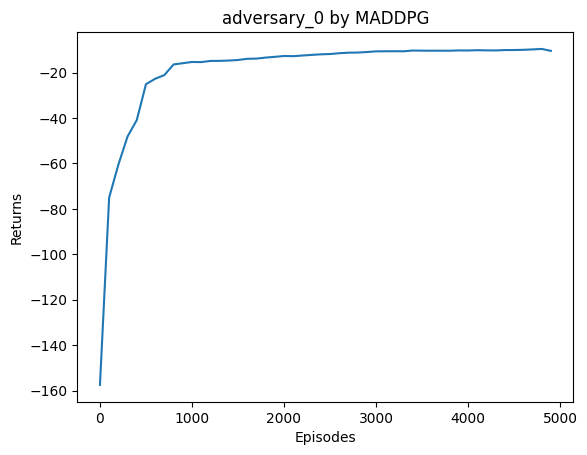

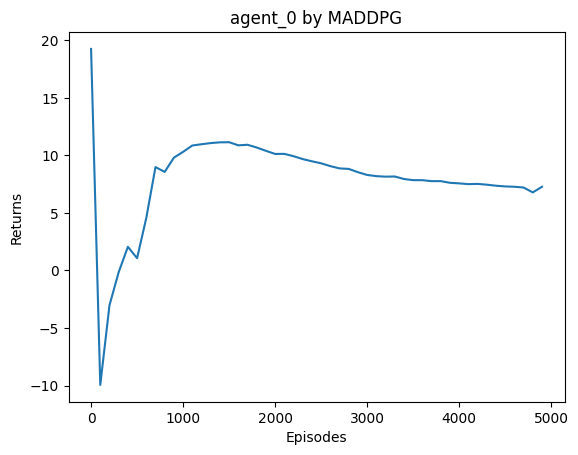

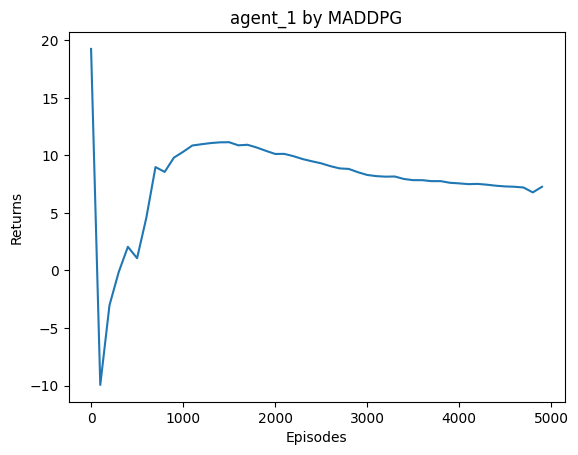

In [179]:
return_array = np.array(return_list)
for i, agent_name in enumerate(["adversary_0", "agent_0", "agent_1"]):
    plt.figure()
    plt.plot(
        np.arange(return_array.shape[0]) * 100,
        rl_utils.moving_average(return_array[:, i], 9))
    plt.xlabel("Episodes")
    plt.ylabel("Returns")
    plt.title(f"{agent_name} by MADDPG")